# Digit Recognizer - MNIST

Digit Recognizer, using the famous MNIST Digit DataSet.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras_tuner as kt
import os
import os.path

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

# Initialize tf.distribute.MirroredStrategy
strategy = tf.distribute.MirroredStrategy(devices=None)
print('Number of devices: {}'.format(strategy.num_replicas_in_sync))

2024-08-21 14:26:25.173497: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-21 14:26:25.173649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-21 14:26:25.305092: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Number of devices: 1


In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.15.0


## Setting Variables
Variables used for training the models

In [3]:
BATCH_SIZE = 64
EPOCHS = 128
DATA_SPLIT = 0.2
BUFFER_SIZE = 256

# Learning rate and decay over time
learning_decay_step: int = 1200
learning_decay_rate: float = 0.96

In [4]:
root_dir = "result/mnist_recognition"
if not os.path.exists(root_dir):
    os.makedirs(root_dir)

## Load and Process MNIST Data

In [5]:
train_df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test_df = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

In [6]:
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [8]:
# Extract Image And Label Data
trainX = train_df.drop(columns=['label'])
trainX = np.array(trainX).reshape((trainX.shape[0], 28,28, 1))
trainY = np.array(train_df['label'])

# Exract only Image Data from the Test
testX = test_df
testX = np.array(testX).reshape((testX.shape[0], 28,28,1))

# Split to allow a subset of validation data, for later choicing a good model.
X_train, X_val, y_train, y_val = train_test_split(trainX, trainY, test_size=DATA_SPLIT)

# Convert to a DataSet Object
trainDS = tf.data.Dataset.from_tensor_slices((X_train, y_train))
valDS = tf.data.Dataset.from_tensor_slices((X_val, y_val))

# Convert to a DataSet Object
testDS = tf.data.Dataset.from_tensor_slices(testX)

print('X_train: ' + str(trainX.shape))
print('Y_train: ' + str(trainY.shape))
print('X_test:  '  + str(testX.shape))

X_train: (42000, 28, 28, 1)
Y_train: (42000,)
X_test:  (28000, 28, 28, 1)


## Augment Image Data
One way to prevent overfit with data is by augmenting it. By that, the model will most likly not same the exact data, this case image.

In [9]:

def configure_dataset_performance(ds, use_cache: bool, shuffle_size: int = 0,
                                  prefetch_buffer_size: object = tf.data.AUTOTUNE) :
    if use_cache:
        ds = ds.cache()
    if shuffle_size > 0:
        ds = ds.shuffle(buffer_size=shuffle_size, reshuffle_each_iteration=True)

    ds = ds.prefetch(buffer_size=prefetch_buffer_size)

    return ds

trainAug = tf.keras.Sequential([
    # Random Zoom.
    layers.RandomZoom(
        height_factor=(-0.05, 0.1),
        width_factor=(-0.05, 0.1),
        fill_mode='reflect',
        interpolation='bilinear'),
    layers.RandomRotation(factor=0.095, # To big factor can cause 6 to look like a 9. Which could worses the result
                          fill_mode='reflect',
                          interpolation='bilinear'),
    # Noise
    layers.GaussianNoise(0.5)

])

def AgumentFunc(x, y):
    aX = trainAug(x)
    return (aX, y)

normalization_layer = tf.keras.layers.Rescaling(1. / 255.0)
float_precision = tf.float32

# Cast and Normalized data.
trainDSNormalized = trainDS.map(lambda x, y:  ( normalization_layer(tf.cast(x, float_precision)), y) )
valDSNormalized = valDS.map(lambda x, y:  ( normalization_layer(tf.cast(x, float_precision)), y) )
testDSNormalized = testDS.map(lambda x:  ( normalization_layer(tf.cast(x, float_precision))) )

trainDS = trainDSNormalized.batch(BATCH_SIZE)
valDS = valDSNormalized.batch(BATCH_SIZE)
testDS = testDSNormalized.batch(BATCH_SIZE)


trainDSAug = (
    trainDS
    .map(AgumentFunc,
         num_parallel_calls=tf.data.AUTOTUNE)
)

# Configure dataset for using cache and shuffle data
trainDS = configure_dataset_performance(ds=trainDS, use_cache=True, shuffle_size=512)
trainDSAug = configure_dataset_performance(ds=trainDSAug, use_cache=True, shuffle_size=512)
valDS = configure_dataset_performance(ds=valDS, use_cache=True, shuffle_size=512)
testDS = configure_dataset_performance(ds=testDS, use_cache=True, shuffle_size=0)



# Optional if using multiple GPUs
options = tf.data.Options()
options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.DATA
trainDS = trainDS.with_options(options)

options = tf.data.Options()
options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.DATA
trainDSAug = trainDSAug.with_options(options)

options = tf.data.Options()
options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.DATA
valDS = valDS.with_options(options)

options = tf.data.Options()
options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.DATA
testDS = testDS.with_options(options)

## Present Example Data

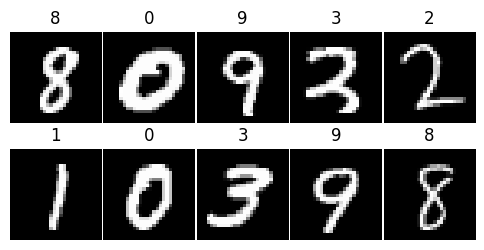

In [10]:
batch_iter = iter(trainDS)
image_batch, expected_batch = next(batch_iter)

plt.figure(figsize=(6, 3))
for index in range(0, 2*5):

    trainImage, expected = (image_batch[index % len(image_batch)], expected_batch[index % len(expected_batch)])

    plt.subplot(2, 5, index + 1)
    plt.title(str.format("{0}", expected))
    plt.imshow(trainImage, cmap=plt.cm.gray)
    plt.axis("off")

    if len(image_batch) - 1 == index:
        image_batch, expected_batch = next(bathc_iter)
plt.subplots_adjust(wspace=0.025, hspace=0.025)
plt.show()

### Augemented Data Example
The following images are augmented.

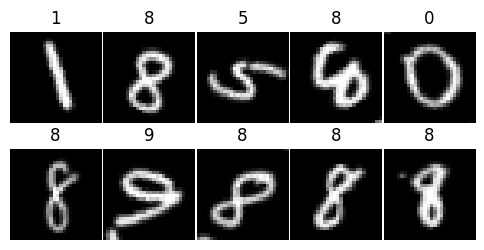

In [11]:
batch_iter = iter(trainDSAug)
image_batch, expected_batch = next(batch_iter)

plt.figure(figsize=(6, 3))
for index in range(0, 2*5):

    trainImage, expected = (image_batch[index % len(image_batch)], expected_batch[index % len(expected_batch)])

    plt.subplot(2, 5, index + 1)
    plt.title(str.format("{0}", expected))
    plt.imshow(trainImage, cmap=plt.cm.gray)
    plt.axis("off")

    if len(image_batch) - 1 == index:
        image_batch, expected_batch = next(bathc_iter)
plt.subplots_adjust(wspace=0.025, hspace=0.025)
plt.show()

In [12]:
def plotCostHistory(history, loss_label ="", val_label = "", title ="", x_label = "", y_label =""):
    for k, v in history.items():
        plt.plot(v, label=k)
    plt.title(label=title)
    plt.ylabel(ylabel=y_label)
    plt.xlabel(xlabel=x_label)
    plt.legend(loc="upper left")
    plt.show()

## Hyperparameter Finding Model
Using hyperparameter to find the best model. 

In [13]:
def generate_cnn_builder(hp, input, output):
    cnn_model = tf.keras.Sequential()
    
    #
    kernel_init = hp.Choice('kernel_initializer', ['uniform', 'lecun_uniform', 'normal', 'zero',
                                                   'glorot_normal', 'glorot_uniform', 'he_normal', 'he_uniform'])

    # TODO add stride.
    hp_kernel_filter_size_l0 = hp.Int('kernel_filter_size_0', min_value=32, max_value=128, step=32)
    hp_kernel_filter_size_l1 = hp.Int('kernel_filter_size_1', min_value=64, max_value=256, step=32)
    hp_kernel_filter_size_l2 = hp.Int('kernel_filter_size_2', min_value=64, max_value=512, step=32)

    # 
    hp_max_pooling_size_l0 = hp.Int('max_pooling_l0', min_value=2, max_value=2, step=1)
    hp_max_pooling_size_l1 = hp.Int('max_pooling_l1', min_value=2, max_value=2, step=1)
    hp_max_pooling_size_l2 = hp.Int('max_pooling_l2', min_value=2, max_value=2, step=1)

    cnn_model.add(layers.Input(input))
    cnn_model.add(
        layers.Conv2D(hp_kernel_filter_size_l0, (4, 4), kernel_initializer=kernel_init, activation='relu',
                      padding='same'))
    cnn_model.add(layers.MaxPooling2D(pool_size=hp_max_pooling_size_l0))

    #
    cnn_model.add(
        layers.Conv2D(hp_kernel_filter_size_l1, (4, 4), activation='relu', kernel_initializer=kernel_init))
    cnn_model.add(layers.MaxPooling2D(pool_size=hp_max_pooling_size_l1))

    cnn_model.add(
        layers.Conv2D(hp_kernel_filter_size_l2, (4, 4), activation='relu', kernel_initializer=kernel_init))
    cnn_model.add(tf.keras.layers.MaxPooling2D(pool_size=hp_max_pooling_size_l2))
    
    hp_dropout = hp.Float('drop0_drop', min_value=0, max_value=0.4, step=0.1)
    cnn_model.add(layers.Dropout(hp_dropout))

    cnn_model.add(layers.Flatten())

    hp_units = hp.Int('dense0_units', min_value=64, max_value=1024, step=64)
    cnn_model.add(layers.Dense(units=hp_units, kernel_initializer=kernel_init))

    cnn_model.add(layers.Dense(output))
    cnn_model.add(layers.ActivityRegularization(l1=0.000008))

    cnn_model.summary()

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-4,1e-5,1e-6])
    
    # 
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        hp_learning_rate,
        decay_steps=learning_decay_step,
        decay_rate=learning_decay_rate,
        staircase=False)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=0.5, beta_2=0.9)
    cnn_model.compile(optimizer=optimizer,
                      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])

    return cnn_model

In [14]:
def hyperparamter_model_builder(hp):
    image_shape = (trainX.shape[1], trainX.shape[2], 1)
    model = generate_cnn_builder(hp, image_shape, 10)
    return model

tuner = kt.Hyperband(hyperparamter_model_builder,
                     objective=kt.Objective("val_accuracy", direction="max"),
                     max_epochs=14,
                     distribution_strategy=strategy,
                     factor=5,
                     directory=os.path.join(root_dir, 'cache'),
                     project_name='MNIST Search')

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3)

tuner.search(trainDSAug, epochs=EPOCHS, batch_size=BATCH_SIZE,
             validation_data=valDS,
             callbacks=[stop_early, tf.keras.callbacks.TerminateOnNaN()], verbose=1)

# Get bets models.
best_model = tuner.get_best_models(num_models=2)[0]

Trial 13 Complete [00h 00m 57s]
val_accuracy: 0.9878571629524231

Best val_accuracy So Far: 0.9878571629524231
Total elapsed time: 00h 06m 56s


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 224)    │       229,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 224)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 480)      │     1,720,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 480)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 1, 480)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       184,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_regularization         │ (None, 10)             │             0 │
│ (ActivityRegularization)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,140,042 (8.16 MB)

 Trainable params: 2,140,042 (8.16 MB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 128)    │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 96)     │       196,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 192)      │       295,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 1, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_regularization         │ (None, 10)             │             0 │
│ (ActivityRegularization)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 506,986 (1.93 MB)

 Trainable params: 506,986 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

## Train Final

In [15]:
checkpoint_filepath = '/tmp/ckpt/checkpoint.weights.h5'
model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

best_model_result = best_model.fit(trainDSAug, validation_data=valDS, epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[model_checkpoint_callback])
best_model.load_weights(checkpoint_filepath)


Epoch 1/128
525/525 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9927 - loss: 0.0409 - val_accuracy: 0.9885 - val_loss: 0.0566
Epoch 2/128
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9950 - loss: 0.0349 - val_accuracy: 0.9845 - val_loss: 0.0651
Epoch 3/128
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9955 - loss: 0.0317 - val_accuracy: 0.9874 - val_loss: 0.0607
Epoch 4/128
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9974 - loss: 0.0264 - val_accuracy: 0.9895 - val_loss: 0.0566
Epoch 5/128
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9981 - loss: 0.0234 - val_accuracy: 0.9880 - val_loss: 0.0566
Epoch 6/128
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9983 - loss: 0.0220 - val_accuracy: 0.9885 - val_loss: 0.0525
Epoch 7/128
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9988 - loss: 0.0201 - val_accuracy: 0.9893 - val_loss: 0.0529
Epoch 8/128
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9991 - loss: 0.0187 - 

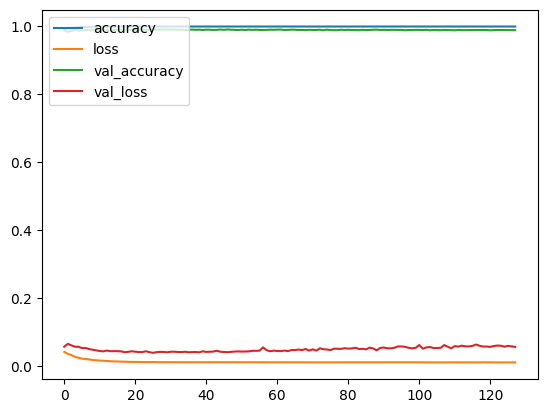

In [16]:
plotCostHistory(best_model_result.history)

# Extract the Result
Extract the model final **accuracy** and **loss** test result. Additionally, the predicted result from the data, used for the submission.

In [17]:
test_loss, test_acc = best_model.evaluate(valDS, verbose=0)
print('\nTest accuracy:', test_acc)
print('\nTest loss:', test_loss)


Test accuracy: 0.9915476441383362

Test loss: 0.03862413763999939


Selecting the predicted label with the highest probability out of all the possible labels.

In [18]:
predictions = best_model.predict(testDS)
predictions = [np.argmax(p) for p in predictions]

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [19]:
df = pd.DataFrame({"ImageId": [index for index in range(1, testX.shape[0] +1)], "Label": predictions})
df.to_csv(str.format('prediction-result-{0}.csv', test_acc), index=False)

### Show Test Data Example and Prediction

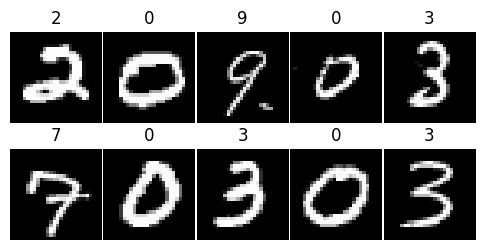

In [20]:
batch_iter = iter(testDS)
image_batch = next(batch_iter)

plt.figure(figsize=(6, 3))
for index in range(0, 2*5):

    trainImage = image_batch[index % len(image_batch)]

    plt.subplot(2, 5, index + 1)
    plt.title(str.format("{0}", predictions[index]))
    plt.imshow(trainImage, cmap=plt.cm.gray)
    plt.axis("off")

    if len(image_batch) - 1 == index:
        image_batch, expected_batch = next(bathc_iter)
plt.subplots_adjust(wspace=0.025, hspace=0.025)
plt.show()